# Regime-Shift: Macro-Aware Tactical Allocation Engine
## Holdout Evaluation

**This notebook executes exactly once. Results are final and are not to be used to
re-tune any prior stage.**

**Holdout period:** January 2024 – December 2024 (12 months)

This notebook unseals the holdout dataset. All design decisions — HMM architecture,
optimizer bounds, persistence parameters, and soft-blend logic — were finalized at the
conclusion of `walkfwd_integration` and remain unchanged here.

**Inputs:**
- `hmm_config.json` (`hmm` output) — HMM architecture, unchanged
- `optimizer_new` (`cvxpy` output) — portfolio construction logic, unchanged
- `metadata.json` (`walkfwd_integration` output) — all v2 parameters, unchanged
- Complete parquet datasets (`data_foundation` output), including the holdout period
- `walkforward_results.parquet` (`walkfwd_integration` output) — in-sample results for comparison

**Outputs:** `data/stage7/` — holdout results, charts, and the final report

In [1]:
import sys, json, pickle, warnings
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM
from scipy import stats

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format

# Project paths
import os
# Reproducibility / portability fix: the notebook previously hardcoded a
# path from one contributor's Windows machine (C:\Users\Gangadhar\...),
# which fails on any other machine or OS. Resolution order:
#   1. REGIME_SHIFT_PROJECT_DIR environment variable, if set
#   2. current working directory (wherever Jupyter/this notebook was launched from
#      -- normally the repo root, Regime-Shift-Quant---1/)
PROJECT_DIR = Path(os.environ.get("REGIME_SHIFT_PROJECT_DIR", Path.cwd()))
DATA_DIR    = PROJECT_DIR / "data"
STAGE3_DIR  = DATA_DIR / "stage3"
STAGE5_DIR  = DATA_DIR / "stage5"
STAGE6_DIR  = DATA_DIR / "stage6"
STAGE7_DIR  = DATA_DIR / "stage7"
STAGE7_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_DIR))
from optimizer_new import (
    solve_regime_objective, validate_weights,
    portfolio_metrics, covariance_health,
    ASSETS, N_ASSETS, BUY_COSTS, SELL_COSTS,
    CVaR_CONFIDENCE, OBJECTIVE_WEIGHTS
)

print("✓ Imports OK")
print(f"  Assets  : {ASSETS}")
print(f"  N_ASSETS: {N_ASSETS}")

✓ Imports OK
  Assets  : ['NIFTYBEES', 'JUNIORBEES', 'GOLDBEES', 'LIQUIDBEES']
  N_ASSETS: 4


In [2]:
#  ALL PARAMETERS LOCKED — copied verbatim from walkfwd_integration v2
#  Do NOT change any value here. The holdout must use identical parameters.

# Periods
BACKTEST_START    = "2010-01-01"
BACKTEST_END      = "2023-12-31"
HOLDOUT_START     = "2024-01-01"
HOLDOUT_END       = "2026-05-31"

# HMM
COV_WINDOW        = 36
RF_ANNUAL         = 0.065
RF_MONTHLY        = (1 + RF_ANNUAL) ** (1/12) - 1

# v2 improvements (ALL locked from walkfwd_integration)
LIQUIDBEES_ANNUAL_RATE  = 0.065
USE_SOFT_BLENDING       = True
ENTRY_CRISIS_MONTHS     = 1
EXIT_CRISIS_MONTHS      = 3
MAGNITUDE_BYPASS_THR    = 0.90
TREND_QUALITY_TILT_THR  = 1.5
TREND_QUALITY_TILT_MAX  = 0.10
PERSIST_MIN_PROB        = 0.65
PERSIST_MIN_MONTHS      = 2
CLIP_SIGMA              = 3.5
HMM_N_INIT             = 20
HMM_N_ITER             = 500
HMM_SEED               = 42

# Load hmm config
with open(STAGE3_DIR / "hmm_config.json") as f:
    hmm_cfg = json.load(f)
with open(STAGE3_DIR / "label_map.json") as f:
    LABEL_MAP_FULL = {int(k): v for k, v in json.load(f).items()}

N_STATES_WIN        = hmm_cfg["n_states"]
COV_TYPE_WIN        = hmm_cfg["cov_type"]
ACTIVE_CRISIS_THR   = hmm_cfg["crisis_conf_thr"]
REGIME_MAPPING      = hmm_cfg["regime_mapping"]
FEATURE_COLS        = hmm_cfg["feature_columns"]
STATE_SCORE_WEIGHTS = hmm_cfg["state_score_weights"]

# Verify against walkfwd_integration metadata
with open(STAGE5_DIR / "metadata.json") as f:
    meta5 = json.load(f)

print("✓ Parameters locked from Walk-Forward Integration v2")
_hs_year = pd.Timestamp(HOLDOUT_START).year
_he_year = pd.Timestamp(HOLDOUT_END).year
HOLDOUT_LABEL = str(_hs_year) if _hs_year == _he_year else f"{_hs_year}–{_he_year}"

print(f"  Holdout : {HOLDOUT_START} → {HOLDOUT_END}")
print(f"  HMM     : n_states={N_STATES_WIN}, cov_type={COV_TYPE_WIN}")
print(f"  Features: {FEATURE_COLS}")
print(f"  v2 soft blending : {USE_SOFT_BLENDING}")
print(f"  v2 persistence   : entry={ENTRY_CRISIS_MONTHS}m Crisis / exit={EXIT_CRISIS_MONTHS}m Bull")
print()
print("  Walk-Forward Integration v2 improvements cross-check:")
v2 = meta5.get("v2_improvements", {})
print(f"    LIQUIDBEES rate  : {v2.get('liquidbees_annual_rate', 'N/A')} (locked: {LIQUIDBEES_ANNUAL_RATE})")
print(f"    Soft blending    : {v2.get('soft_blending', 'N/A')} (locked: {USE_SOFT_BLENDING})")
print(f"    Entry months     : {v2.get('entry_crisis_months', 'N/A')} (locked: {ENTRY_CRISIS_MONTHS})")
print(f"    Exit months      : {v2.get('exit_crisis_months', 'N/A')} (locked: {EXIT_CRISIS_MONTHS})")
print()
print("  ⚠ DO NOT re-tune any parameter after seeing holdout results.")

✓ Parameters locked from Walk-Forward Integration v2
  Holdout : 2024-01-01 → 2026-05-31
  HMM     : n_states=2, cov_type=full
  Features: ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z']
  v2 soft blending : True
  v2 persistence   : entry=1m Crisis / exit=3m Bull

  Walk-Forward Integration v2 improvements cross-check:
    LIQUIDBEES rate  : 0.065 (locked: 0.065)
    Soft blending    : True (locked: True)
    Entry months     : 1 (locked: 1)
    Exit months      : 3 (locked: 3)

  ⚠ DO NOT re-tune any parameter after seeing holdout results.


In [3]:
# HMM helpers (identical to walkfwd_integration v2)

def prepare_features(features, clip=CLIP_SIGMA):
    clean = features.dropna()
    X = np.clip(clean.values, -clip, clip)
    return X, clean.index

def fit_hmm(X, n_states=N_STATES_WIN, cov_type=COV_TYPE_WIN,
            n_init=HMM_N_INIT, n_iter=HMM_N_ITER, seed=HMM_SEED):
    best_model, best_ll = None, -np.inf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(n_init):
            m = GaussianHMM(n_components=n_states, covariance_type=cov_type,
                            n_iter=n_iter, random_state=seed + i, verbose=False)
            try:
                m.fit(X)
                ll = m.score(X)
                if ll > best_ll:
                    best_ll, best_model = ll, m
            except Exception:
                continue
    return best_model, best_ll

def align_states(model, X, feat_cols=FEATURE_COLS, weights=STATE_SCORE_WEIGHTS):
    states = model.predict(X)
    n = model.n_components
    composite = {}
    for s in range(n):
        mask = (states == s)
        vals = X[mask] if mask.sum() > 0 else model.means_[s:s+1]
        composite[s] = sum(
            weights.get(col, 0.0) * vals[:, j].mean()
            for j, col in enumerate(feat_cols)
        )
    sorted_s = sorted(composite, key=composite.get, reverse=True)
    labels = (["Bull","MildBull","Bear","Crisis"] if n == 4
              else ["Bull","Bear","Crisis"] if n == 3
              else ["Bull","Crisis"])
    return {sorted_s[i]: labels[i] for i in range(n)}

def decode_regime(model, label_map, X_to_date, crisis_thr=ACTIVE_CRISIS_THR):
    proba_mat    = model.predict_proba(X_to_date)
    last_proba   = proba_mat[-1]
    regime_proba = {label_map[s]: float(last_proba[s]) for s in range(model.n_components)}
    if crisis_thr > 0 and regime_proba.get("Crisis", 0) < crisis_thr:
        no_crisis = {k: v for k, v in regime_proba.items() if k != "Crisis"}
        opt = max(no_crisis, key=no_crisis.get) if no_crisis else "Bull"
    else:
        opt = max(regime_proba, key=regime_proba.get)
    return opt, regime_proba

def rolling_ledoit_wolf(ret_window):
    R = ret_window[ASSETS].dropna().values
    if R.shape[0] < max(6, len(ASSETS) + 1):
        vols = np.nanstd(R, axis=0)
        return np.diag(vols ** 2)
    lw = LedoitWolf()
    lw.fit(R)
    return lw.covariance_

class PersistenceFilter:
    def __init__(self, default="Bull",
                 entry_crisis_months=ENTRY_CRISIS_MONTHS,
                 exit_crisis_months=EXIT_CRISIS_MONTHS,
                 min_months=PERSIST_MIN_MONTHS,
                 min_prob=PERSIST_MIN_PROB):
        self.confirmed           = default
        self.candidate           = None
        self.count               = 0
        self.entry_crisis_months = entry_crisis_months
        self.exit_crisis_months  = exit_crisis_months
        self.min_months          = min_months
        self.min_prob            = min_prob

    def _required(self, from_r, to_r):
        if from_r != "Crisis" and to_r == "Crisis":
            return self.entry_crisis_months
        elif from_r == "Crisis" and to_r != "Crisis":
            return self.exit_crisis_months
        return self.min_months

    def update(self, new_regime, new_prob):
        if new_prob < self.min_prob:
            self.candidate = None; self.count = 0
            return self.confirmed
        if new_regime == self.confirmed:
            self.candidate = None; self.count = 0
        elif new_regime == self.candidate:
            self.count += 1
            if self.count >= self._required(self.confirmed, new_regime):
                self.confirmed = new_regime
                self.candidate = None; self.count = 0
        else:
            self.candidate = new_regime; self.count = 1
        return self.confirmed

    def reset(self, regime="Bull"):
        self.confirmed = regime
        self.candidate = None; self.count = 0

print("✓ HMM helpers defined (identical to Walk-Forward Integration v2)")

✓ HMM helpers defined (identical to Walk-Forward Integration v2)


In [4]:
# Load full feature and return data (training + holdout)
feat_train_file = DATA_DIR / "monthly" / "hmm_features_train.parquet"
feat_holdout_file = DATA_DIR / "monthly" / "hmm_features_holdout.parquet"
ret_train_file = DATA_DIR / "monthly" / "etf_returns_train.parquet"
ret_holdout_file = DATA_DIR / "monthly" / "etf_returns_holdout.parquet"

feat_train = pd.read_parquet(feat_train_file)
ret_train  = pd.read_parquet(ret_train_file)
feat_holdout = pd.read_parquet(feat_holdout_file)
ret_holdout  = pd.read_parquet(ret_holdout_file)

# Full dataset for convenience (holdout combines training + holdout months)
feat_all = pd.concat([feat_train, feat_holdout]).sort_index()
ret_all  = pd.concat([ret_train, ret_holdout]).sort_index()

# Training slice (same as walkfwd_integration)
feat_train = feat_all.loc[:BACKTEST_END, FEATURE_COLS].copy()
ret_train  = ret_all.loc[:BACKTEST_END, ASSETS].copy()

# LIQUIDBEES override (same 6.5% flat rate as walkfwd_integration)
if LIQUIDBEES_ANNUAL_RATE > 0:
    liq_monthly = (1 + LIQUIDBEES_ANNUAL_RATE) ** (1/12) - 1
    ret_train   = ret_train.copy()
    ret_train["LIQUIDBEES"] = liq_monthly

# Holdout slice — UNSEALED NOW
feat_holdout = feat_all.loc[HOLDOUT_START:HOLDOUT_END, FEATURE_COLS].copy()
ret_holdout  = ret_all.loc[HOLDOUT_START:HOLDOUT_END, ASSETS].copy()

# Apply same LIQUIDBEES override to holdout
if LIQUIDBEES_ANNUAL_RATE > 0:
    ret_holdout = ret_holdout.copy()
    ret_holdout["LIQUIDBEES"] = liq_monthly
    print(f"  LIQUIDBEES override: {LIQUIDBEES_ANNUAL_RATE:.1%}/yr applied to holdout")

print(f"✓ Training   : {feat_train.shape}  {feat_train.index[0].date()} → {feat_train.index[-1].date()}")
print(f"✓ Holdout    : {feat_holdout.shape}  {feat_holdout.index[0].date()} → {feat_holdout.index[-1].date()}")
print()
print("Holdout ETF return stats:")
hld_summary = pd.DataFrame({
    "ann_ret": (1 + ret_holdout).prod() ** (12 / len(ret_holdout)) - 1,
    "ann_vol": ret_holdout.std() * np.sqrt(12),
    "min_mo" : ret_holdout.min(),
    "max_mo" : ret_holdout.max(),
})
print((hld_summary * 100).round(2).to_string())


  LIQUIDBEES override: 6.5%/yr applied to holdout
✓ Training   : (168, 6)  2010-01-31 → 2023-12-31
✓ Holdout    : (29, 6)  2024-01-31 → 2026-05-29

Holdout ETF return stats:
            ann_ret  ann_vol   min_mo  max_mo
NIFTYBEES    4.5700  13.5700 -11.1600  7.3300
JUNIORBEES  13.2800  20.3500 -13.1400 15.4800
GOLDBEES    43.5100  17.7600  -7.9100 19.0800
LIQUIDBEES   6.5000   0.0000   0.5300  0.5300


In [5]:
# Fit the FINAL HMM on ALL training data (Jan 2010 – Dec 2023)
# This is the model that was "production-ready" at the end of hmm.
# It uses 168 months vs the 128 months used for the 2023 walk-forward fold.
# No holdout data is used or seen here.

X_full, idx_full = prepare_features(feat_train)
print(f"Fitting final HMM on {len(X_full)} months of training data …")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_model, final_ll = fit_hmm(X_full)

assert final_model is not None, "Final HMM fit failed — check data and n_init"
final_lmap = align_states(final_model, X_full)

print(f"✓ Final HMM fitted")
print(f"  Log-likelihood/obs : {final_ll / len(X_full):.4f}")
print(f"  State → label map  : {final_lmap}")

# Sanity check: regime distribution on full training data
train_states = final_model.predict(X_full)
for s, lbl in final_lmap.items():
    n_s = (train_states == s).sum()
    print(f"  {lbl:8s} (state {s}): {n_s:3d} months ({n_s/len(X_full):.0%})")

# What was the regime at end of training (Dec 2023)?
_, regime_proba_dec23 = decode_regime(final_model, final_lmap, X_full)
last_regime = max(regime_proba_dec23, key=regime_proba_dec23.get)
print()
print(f"  Regime at Dec 2023 (end of training):")
for r, p in sorted(regime_proba_dec23.items(), key=lambda x: -x[1]):
    print(f"    {r}: {p:.3f}")
print(f"  → Confirmed: {last_regime} (PersistenceFilter initialized here)")

Fitting final HMM on 139 months of training data …
✓ Final HMM fitted
  Log-likelihood/obs : -6.5534
  State → label map  : {1: 'Bull', 0: 'Crisis'}
  Bull     (state 1):  86 months (62%)
  Crisis   (state 0):  53 months (38%)

  Regime at Dec 2023 (end of training):
    Bull: 0.999
    Crisis: 0.001
  → Confirmed: Bull (PersistenceFilter initialized here)


In [6]:
# Bridge rebalance: compute Dec 2023 weights to initialize holdout
# In walkfwd_integration, the Dec 2023 rebalance was executed but the return dropped
# (Jan 2024 is holdout). This rebalance is re-executed here to obtain w_prev.

bridge_date = feat_train.index[-1]   # 2023-12-29
X_bridge, _ = prepare_features(feat_train.loc[:bridge_date, FEATURE_COLS])

opt_bridge, regime_proba_bridge = decode_regime(final_model, final_lmap, X_bridge)
P_crisis_bridge = regime_proba_bridge.get("Crisis", 0.0)
P_bull_bridge   = 1.0 - P_crisis_bridge

ret_window_bridge = ret_train.iloc[-COV_WINDOW:]
sigma_bridge      = rolling_ledoit_wolf(ret_window_bridge)
scenarios_bridge  = ret_window_bridge[ASSETS].dropna().values

w_init = np.ones(N_ASSETS) / N_ASSETS   # equal weight as starting point

if USE_SOFT_BLENDING:
    res_b = solve_regime_objective("Bull",   sigma_bridge, scenarios_bridge, w_init, reject_singular=True)
    res_c = solve_regime_objective("Crisis", sigma_bridge, scenarios_bridge, w_init, reject_singular=True)
    w_dec23 = P_bull_bridge * res_b["weights"] + P_crisis_bridge * res_c["weights"]
    w_dec23 = np.clip(w_dec23, 0, 1); w_dec23 /= w_dec23.sum()
else:
    res = solve_regime_objective(opt_bridge, sigma_bridge, scenarios_bridge, w_init)
    w_dec23 = res["weights"]

print(f"✓ Dec 2023 bridge rebalance computed")
print(f"  P(Crisis) at Dec 2023 : {P_crisis_bridge:.3f}")
print(f"  Initial weights for holdout:")
for a, w in zip(ASSETS, w_dec23):
    print(f"    {a:12s}: {w:.1%}")

# Initialize PersistenceFilter at Dec 2023 regime
# From the annual breakdown (walkfwd_integration), Dec 2023 was Bull
# Confirm from the bridge decode
persist_init = last_regime   # regime at end of training
print(f"\n  PersistenceFilter initialized at: '{persist_init}'")

✓ Dec 2023 bridge rebalance computed
  P(Crisis) at Dec 2023 : 0.001
  Initial weights for holdout:
    NIFTYBEES   : 50.0%
    JUNIORBEES  : 25.0%
    GOLDBEES    : 15.0%
    LIQUIDBEES  : 10.0%

  PersistenceFilter initialized at: 'Bull'


In [7]:
#  HOLDOUT WALK — dates driven by HOLDOUT_START/HOLDOUT_END (see config cell)
#  Applies walkfwd_integration v2 logic exactly: soft blend, asymmetric persistence,
#  magnitude bypass, trend-quality tilt. HMM is NOT refitted on holdout data.
#
#  Every return is indexed by the PERIOD IT WAS EARNED IN, not the date the
#  decision was made. Two consequences of this convention, both intentional:
#    1. The Dec-2023-decided bridge weights (w_dec23, from the previous cell)
#       are the position actually held entering the holdout — so the FIRST
#       holdout period's return belongs to that decision, not to a fresh
#       decision made using that same period's own data. Without this, the
#       first period's return is silently uncounted.
#    2. A decision made at date D is credited with the return of the NEXT
#       available date after D, and stored under THAT date. This keeps wh's
#       index on the same convention as ret_holdout / bh_h / ew_h, so every
#       downstream comparison (Cell 9's monthly table, Cell 10's chart) lines
#       up period-for-period without further adjustment. Previously, rows
#       were labeled by decision date while containing the FOLLOWING period's
#       return — every row was mislabeled by one period.
#  The final decision date has no next period within the sealed holdout
#  window and is correctly left unscored.

TQ_COL = "trend_quality_z" if "trend_quality_z" in FEATURE_COLS else None
TQ_IDX = FEATURE_COLS.index(TQ_COL) if TQ_COL else None

holdout_dates = feat_holdout.dropna().index
if len(holdout_dates) == 0:
    raise RuntimeError("No holdout dates found — check feat_holdout dates align with HOLDOUT_START/END")

w_prev = w_dec23.copy()
persist = PersistenceFilter(
    default             = persist_init,
    entry_crisis_months = ENTRY_CRISIS_MONTHS,
    exit_crisis_months  = EXIT_CRISIS_MONTHS,
    min_prob            = PERSIST_MIN_PROB,
)

records = []
# Full feature history up to each holdout date (for predict_proba continuity)
feat_full = feat_all.loc[:HOLDOUT_END, FEATURE_COLS].copy()

print(f"Holdout walk: {len(holdout_dates)} decision dates available")
print(f"  {holdout_dates[0].date()} → {holdout_dates[-1].date()}\n")

# ── Bridge record: Dec-2023-decided weights (w_dec23) earn the first period ──
# Apply the same trend-quality tilt and magnitude-bypass check every other
# period receives below, so the bridge is treated identically rather than as
# a silent special case.
bridge_tq_z = float(X_bridge[-1, TQ_IDX]) if (TQ_IDX is not None and len(X_bridge) > 0) else 0.0
bridge_trend_tilt = 0.0
bridge_P_crisis = P_crisis_bridge
if bridge_tq_z > TREND_QUALITY_TILT_THR:
    bridge_trend_tilt = min(TREND_QUALITY_TILT_MAX,
                            (bridge_tq_z - TREND_QUALITY_TILT_THR) * TREND_QUALITY_TILT_MAX)
    bridge_P_crisis = max(0.0, P_crisis_bridge - bridge_trend_tilt)
bridge_P_bull = 1.0 - bridge_P_crisis

bridge_magnitude_bypass = bridge_P_crisis >= MAGNITUDE_BYPASS_THR
if bridge_magnitude_bypass:
    bridge_confirmed_regime = "Crisis"
    persist.reset("Crisis")
else:
    bridge_confirmed_regime = persist.update(opt_bridge, max(regime_proba_bridge.values()))

first_earn_date = holdout_dates[0]
if first_earn_date in ret_holdout.index:
    bridge_ret      = ret_holdout.loc[first_earn_date, ASSETS].fillna(0).values
    bridge_port_ret = float(w_dec23 @ bridge_ret)
    records.append({
        "date"             : first_earn_date,
        "decided_at"       : bridge_date,
        "raw_regime"       : opt_bridge,
        "confirmed_regime" : bridge_confirmed_regime,
        "P_crisis"         : round(bridge_P_crisis, 4),
        "P_bull"           : round(bridge_P_bull, 4),
        "trend_quality_z"  : round(bridge_tq_z, 4),
        "trend_tilt"       : round(bridge_trend_tilt, 4),
        "magnitude_bypass" : bridge_magnitude_bypass,
        **{f"p_{k}": round(v, 4) for k, v in regime_proba_bridge.items()},
        **{f"w_{a}": round(w_dec23[i], 6) for i, a in enumerate(ASSETS)},
        "port_return"      : bridge_port_ret,
        "turnover"         : 0.0,
        "buy_bps"          : 0.0,
        "sell_bps"         : 0.0,
        "round_trip_bps"   : 0.0,
        "solver_ok"        : True,
    })
    print(f"  {bridge_date.date()} → {first_earn_date.date()}  (bridge)  "
          f"{bridge_confirmed_regime:8s}  P(Crisis)={bridge_P_crisis:.2f}  "
          f"NIFTY={w_dec23[ASSETS.index('NIFTYBEES')]:.0%}  ret={bridge_port_ret:.2%}")

# ── Main loop — decide at each holdout date, credit the NEXT available date ──
for rebal_date in holdout_dates:
    # Decode: use ALL history up to rebal_date (training + prior holdout months)
    feat_to_date = feat_full.loc[:rebal_date, FEATURE_COLS]
    X_to_date, _ = prepare_features(feat_to_date)

    opt_regime, regime_proba = decode_regime(final_model, final_lmap, X_to_date)
    P_crisis = regime_proba.get("Crisis", 0.0)
    P_bull   = 1.0 - P_crisis

    # Trend-quality tilt
    tq_z = float(X_to_date[-1, TQ_IDX]) if (TQ_IDX is not None and len(X_to_date) > 0) else 0.0
    trend_tilt = 0.0
    if tq_z > TREND_QUALITY_TILT_THR:
        trend_tilt = min(TREND_QUALITY_TILT_MAX, (tq_z - TREND_QUALITY_TILT_THR) * TREND_QUALITY_TILT_MAX)
        P_crisis   = max(0.0, P_crisis - trend_tilt)
        P_bull     = 1.0 - P_crisis

    # Magnitude bypass
    magnitude_bypass = P_crisis >= MAGNITUDE_BYPASS_THR
    if magnitude_bypass:
        confirmed_regime = "Crisis"
        persist.reset("Crisis")
    else:
        confirmed_regime = persist.update(opt_regime, max(regime_proba.values()))

    # Covariance: use last COV_WINDOW months of TRAINING data only
    # (not holdout returns — those are future data from the optimizer's perspective)
    ret_for_cov = pd.concat([ret_train, ret_holdout.loc[:rebal_date]]).iloc[-COV_WINDOW:]
    sigma      = rolling_ledoit_wolf(ret_for_cov)
    scenarios  = ret_for_cov[ASSETS].dropna().values

    # Portfolio weights
    if USE_SOFT_BLENDING:
        res_bull   = solve_regime_objective("Bull",   sigma, scenarios, w_prev, reject_singular=True)
        res_crisis = solve_regime_objective("Crisis", sigma, scenarios, w_prev, reject_singular=True)
        w_bull     = res_bull["weights"]
        w_crisis   = res_crisis["weights"]
        w_new      = P_bull * w_bull + P_crisis * w_crisis
        w_new      = np.clip(w_new, 0, 1); w_new /= w_new.sum()
        solver_ok  = (not res_bull["fallback"]) and (not res_crisis["fallback"])
    else:
        res    = solve_regime_objective(confirmed_regime, sigma, scenarios, w_prev, reject_singular=True)
        w_new  = res["weights"]
        solver_ok = not res["fallback"]

    # Realised portfolio return — credited to the NEXT available date, and
    # the record is stored under THAT date (see cell header for rationale).
    future_dates = holdout_dates[holdout_dates > rebal_date]
    port_ret  = np.nan
    next_date = None
    if len(future_dates) > 0:
        next_date = future_dates[0]
        if next_date in ret_holdout.index:
            next_ret = ret_holdout.loc[next_date, ASSETS].fillna(0).values
            port_ret = float(w_new @ next_ret)

    delta    = w_new - w_prev
    buy_bps  = float(np.maximum(delta,  0) @ (BUY_COSTS  * 10_000))
    sell_bps = float(np.maximum(-delta, 0) @ (SELL_COSTS * 10_000))

    if next_date is not None and not np.isnan(port_ret):
        records.append({
            "date"             : next_date,
            "decided_at"       : rebal_date,
            "raw_regime"       : opt_regime,
            "confirmed_regime" : confirmed_regime,
            "P_crisis"         : round(P_crisis, 4),
            "P_bull"           : round(P_bull, 4),
            "trend_quality_z"  : round(tq_z, 4),
            "trend_tilt"       : round(trend_tilt, 4),
            "magnitude_bypass" : magnitude_bypass,
            **{f"p_{k}": round(v, 4) for k, v in regime_proba.items()},
            **{f"w_{a}": round(w_new[i], 6) for i, a in enumerate(ASSETS)},
            "port_return"      : port_ret,
            "turnover"         : round(float(np.abs(delta).sum() / 2), 6),
            "buy_bps"          : round(buy_bps, 4),
            "sell_bps"         : round(sell_bps, 4),
            "round_trip_bps"   : round(buy_bps + sell_bps, 4),
            "solver_ok"        : solver_ok,
        })
        print(f"  {rebal_date.date()} → {next_date.date()}  {confirmed_regime:8s}  "
              f"P(Crisis)={P_crisis:.2f}  NIFTY={w_new[ASSETS.index('NIFTYBEES')]:.0%}  "
              f"ret={port_ret:.2%}")
    else:
        print(f"  {rebal_date.date()} → (none)      {confirmed_regime:8s}  "
              f"P(Crisis)={P_crisis:.2f}  NIFTY={w_new[ASSETS.index('NIFTYBEES')]:.0%}  "
              f"ret=   n/a  [dropped: no next-period return within holdout window]")

    w_prev = w_new.copy()

wh = pd.DataFrame(records).set_index("date")
wh.index = pd.to_datetime(wh.index)
wh = wh.sort_index()
wh = wh.dropna(subset=["port_return"])
print(f"\n✓ Holdout complete: {len(wh)} months  ({wh.index[0].date()} → {wh.index[-1].date()})")

Holdout walk: 28 decision dates available
  2024-01-31 → 2026-04-30

  2023-12-31 → 2024-01-31  (bridge)  Bull      P(Crisis)=0.00  NIFTY=50%  ret=0.87%
  2024-01-31 → 2024-02-29  Crisis    P(Crisis)=1.00  NIFTY=10%  ret=0.38%
  2024-02-29 → 2024-03-31  Crisis    P(Crisis)=0.00  NIFTY=60%  ret=2.47%
  2024-03-31 → 2024-04-29  Crisis    P(Crisis)=0.99  NIFTY=10%  ret=2.52%
  2024-04-29 → 2024-05-30  Crisis    P(Crisis)=0.79  NIFTY=20%  ret=0.83%
  2024-05-30 → 2024-06-30  Crisis    P(Crisis)=0.99  NIFTY=10%  ret=0.71%
  2024-06-30 → 2024-07-31  Crisis    P(Crisis)=1.00  NIFTY=10%  ret=-0.35%
  2024-07-31 → 2024-08-29  Crisis    P(Crisis)=0.00  NIFTY=60%  ret=1.24%
  2024-08-29 → 2024-09-30  Crisis    P(Crisis)=0.92  NIFTY=14%  ret=2.76%
  2024-09-30 → 2024-10-31  Crisis    P(Crisis)=0.36  NIFTY=42%  ret=-2.13%
  2024-10-31 → 2024-11-28  Crisis    P(Crisis)=0.98  NIFTY=11%  ret=-1.51%
  2024-11-28 → 2024-12-31  Crisis    P(Crisis)=1.00  NIFTY=10%  ret=-0.32%
  2024-12-31 → 2025-01-31  Cr

In [8]:
# Build benchmark returns for holdout period
def build_bh(ret_df, asset, label):
    return ret_df[asset].rename(label)

def build_static(weights_dict, ret_df, label):
    w_target = np.array([weights_dict.get(a, 0.0) for a in ASSETS])
    w_prev_s = w_target.copy(); rets = []
    for date in ret_df.index:
        r = ret_df.loc[date, ASSETS].fillna(0).values
        delta   = w_target - w_prev_s
        tc_drag = float(np.maximum(delta,0)@BUY_COSTS + np.maximum(-delta,0)@SELL_COSTS)
        rets.append(float(w_target @ r) - tc_drag)
        w_drift = w_target * (1 + r); w_prev_s = w_drift / w_drift.sum()
    return pd.Series(rets, index=ret_df.index, name=label)

holdout_rets  = wh["port_return"]
bh_h          = build_bh(ret_holdout, "NIFTYBEES", "NIFTYBEES B&H")
ew_h          = build_static({a: 1/N_ASSETS for a in ASSETS}, ret_holdout, "Equal Weight")
india_6040_h  = build_static(
    {"NIFTYBEES":0.40,"JUNIORBEES":0.20,"GOLDBEES":0.25,"LIQUIDBEES":0.15},
    ret_holdout, "60/40 India"
)

def perf(r, label):
    r = r.dropna(); n = len(r)
    cagr    = (1+r).prod()**(12/n)-1
    vol     = r.std()*np.sqrt(12)
    sharpe  = (r.mean()-RF_MONTHLY)/(r.std()+1e-10)*np.sqrt(12)
    down    = r[r < RF_MONTHLY]
    dd_std  = down.std()*np.sqrt(12) if len(down) else 1e-10
    sortino = (cagr-RF_ANNUAL)/(dd_std+1e-10)
    cum     = (1+r).cumprod()
    mdd     = ((cum-cum.cummax())/cum.cummax()).min()
    calmar  = cagr/abs(mdd) if mdd else 0
    win     = (r > RF_MONTHLY).mean()
    return dict(Strategy=label, CAGR=f"{cagr:.1%}", Vol=f"{vol:.1%}",
                Sharpe=f"{sharpe:.3f}", Sortino=f"{sortino:.3f}",
                MaxDD=f"{mdd:.1%}", Calmar=f"{calmar:.3f}",
                WinRate=f"{win:.0%}", N=n,
                _cagr=cagr, _sharpe=sharpe, _mdd=mdd, _calmar=calmar)

rows = [perf(holdout_rets,"REGIME-SHIFT v2"), perf(bh_h,"NIFTYBEES B&H"),
        perf(ew_h,"Equal Weight"), perf(india_6040_h,"60/40 India")]
htbl = pd.DataFrame(rows).set_index("Strategy")

print("="*70)
print(f"HOLDOUT PERFORMANCE  —  {HOLDOUT_START} → {HOLDOUT_END}  ({len(wh)} months)")
print("="*70)
print(htbl.drop(columns=[c for c in htbl.columns if c.startswith("_")]).to_string())
print("="*70)

# In-sample reference, loaded dynamically from walkfwd_integration's saved
# output rather than hardcoded, so this always reflects the current pipeline
# rather than a snapshot from an earlier version of the optimizer objective.
_perf_summary = pd.read_csv(STAGE5_DIR / "performance_summary.csv", index_col="Strategy")
_rs_row = _perf_summary.loc["REGIME-SHIFT"]

def _pct_to_float(s):
    return float(str(s).strip().rstrip("%")) / 100

IS = {
    "cagr":   _pct_to_float(_rs_row["CAGR"]),
    "sharpe": float(_rs_row["Sharpe"]),
    "maxdd":  _pct_to_float(_rs_row["Max DD"]),
    "calmar": float(_rs_row["Calmar"]),
    "vol":    _pct_to_float(_rs_row["Ann. Vol"]),
}
rs_row = rows[0]
print(f"\nHoldout vs in-sample comparison:")
print(f"  {'':25s}  {'In-sample':>12}  {'Holdout':>12}  {'Delta':>10}")
print("  " + "-"*60)
for metric, is_val, h_key in [
    ("CAGR",   IS["cagr"],   "_cagr"),
    ("Sharpe", IS["sharpe"], "_sharpe"),
    ("Max DD", IS["maxdd"],  "_mdd"),
    ("Calmar", IS["calmar"], "_calmar"),
]:
    h_val = rs_row[h_key]
    delta = h_val - is_val
    flag  = "✓" if abs(delta) < 0.15 or metric == "Calmar" else "⚠"
    print(f"  {flag} {metric:23s}  {is_val:>12.3f}  {h_val:>12.3f}  {delta:>+10.3f}")

HOLDOUT PERFORMANCE  —  2024-01-01 → 2026-05-31  (28 months)
                  CAGR    Vol  Sharpe Sortino   MaxDD Calmar WinRate   N
Strategy                                                                
REGIME-SHIFT v2  14.2%   7.0%   1.027   1.230   -5.1%  2.764     68%  28
NIFTYBEES B&H     4.6%  13.6%  -0.069  -0.175  -14.5%  0.315     52%  29
Equal Weight     16.8%   9.4%   1.034   1.100   -7.9%  2.122     72%  29
60/40 India      16.1%  10.3%   0.891   0.905   -9.0%  1.788     72%  29

Holdout vs in-sample comparison:
                                In-sample       Holdout       Delta
  ------------------------------------------------------------
  ✓ CAGR                            0.121         0.142      +0.021
  ⚠ Sharpe                          0.626         1.027      +0.401
  ✓ Max DD                         -0.077        -0.051      +0.026
  ✓ Calmar                          1.575         2.764      +1.189


In [9]:
# Monthly return detail
print("HOLDOUT MONTHLY DETAIL")
print("  (each row: decision made at 'Decided', return earned in 'Month')")
print(f"  {'Decided':>12}  {'Month':>12}  {'Regime':>8}  {'P(Crs)':>8}  "
      f"{'NIFTY%':>8}  {'RS v2%':>8}  {'B&H%':>8}  {'Bypass':>7}")
print("  " + "-"*90)

for date in wh.index:
    decided = wh.loc[date, "decided_at"]
    regime  = wh.loc[date,"confirmed_regime"]
    pc      = wh.loc[date,"P_crisis"]
    rs_ret  = wh.loc[date,"port_return"]
    bh_ret  = bh_h.reindex([date]).iloc[0] if date in bh_h.index else np.nan
    bypass  = "✓" if wh.loc[date,"magnitude_bypass"] else ""
    col     = "🟢" if rs_ret > 0 else "🔴"
    nifty_w = wh.loc[date, "w_NIFTYBEES"] if "w_NIFTYBEES" in wh.columns else np.nan
    decided_str = pd.Timestamp(decided).date() if pd.notna(decided) else "—"
    print(f"  {col} {str(decided_str):>12}  {str(date.date()):>12}  {regime:>8}  {pc:>8.2f}  "
          f"{nifty_w:>7.0%}  {rs_ret:>+7.2%}  {bh_ret:>+7.2%}  {bypass:>7}")

print()
print(f"  Regime distribution:")
for r in ["Bull","Crisis"]:
    n = (wh["confirmed_regime"] == r).sum()
    print(f"    {r:8s}: {n:2d} months ({n/len(wh):.0%})")
print(f"  Magnitude bypass triggered: {wh['magnitude_bypass'].sum()} months")
print(f"  Avg P(Crisis): {wh['P_crisis'].mean():.3f}")
print(f"  Avg turnover : {wh['turnover'].mean():.1%}/month")

HOLDOUT MONTHLY DETAIL
  (each row: decision made at 'Decided', return earned in 'Month')
       Decided         Month    Regime    P(Crs)    NIFTY%    RS v2%      B&H%   Bypass
  ------------------------------------------------------------------------------------------
  🟢   2023-12-31    2024-01-31      Bull      0.00      50%   +0.87%   -0.13%         
  🟢   2024-01-31    2024-02-29    Crisis      1.00      10%   +0.38%   +2.84%        ✓
  🟢   2024-02-29    2024-03-31    Crisis      0.00      60%   +2.47%   +0.54%         
  🟢   2024-03-31    2024-04-29    Crisis      0.99      10%   +2.52%   +0.75%        ✓
  🟢   2024-04-29    2024-05-30    Crisis      0.79      20%   +0.83%   +0.44%         
  🟢   2024-05-30    2024-06-30    Crisis      0.99      10%   +0.71%   +6.83%        ✓
  🔴   2024-06-30    2024-07-31    Crisis      1.00      10%   -0.35%   +3.74%        ✓
  🟢   2024-07-31    2024-08-29    Crisis      0.00      60%   +1.24%   +0.99%         
  🟢   2024-08-29    2024-09-30   

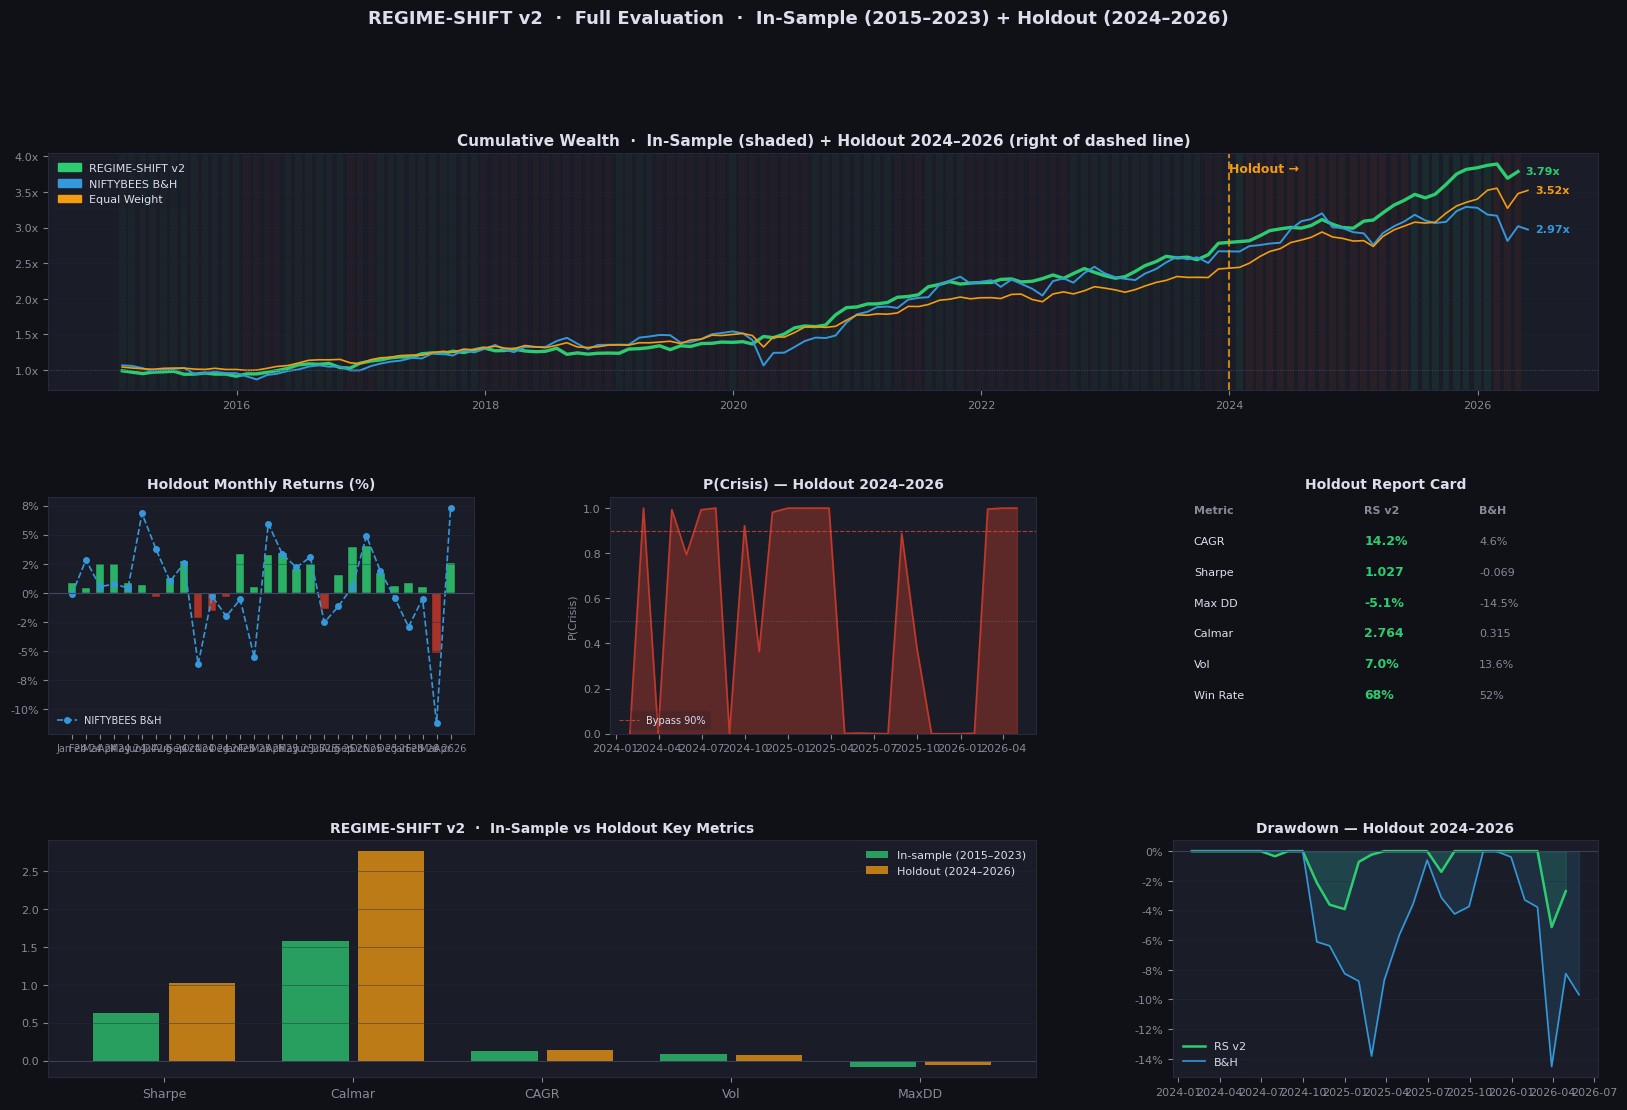

✓ chart_holdout_full_evaluation.png


In [10]:
# Load in-sample results for combined chart
wf_is  = pd.read_parquet(STAGE5_DIR / "walkforward_results.parquet")
wf_is.index = pd.to_datetime(wf_is.index)
is_rets_series = wf_is["port_return"].dropna()

all_rets_is = pd.read_csv(STAGE5_DIR / "all_returns.csv", index_col=0, parse_dates=True)
bh_is       = all_rets_is["niftybees_bh"]
ew_is       = all_rets_is["equal_weight"]

BG, AX_BG, GRID_COL, TEXT, MUTED = "#0F1117","#1A1D27","#262840","#DDDDEE","#888899"
PALETTE = {"Bull":"#27AE60","Crisis":"#C0392B"}

def style_ax(ax, grid=True):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.spines[:].set_color(GRID_COL)
    for lb in ax.get_xticklabels()+ax.get_yticklabels(): lb.set_color(MUTED)
    if grid: ax.grid(axis="y",color=GRID_COL,lw=0.5,alpha=0.6)
def title(ax,t,fs=10): ax.set_title(t,color=TEXT,fontsize=fs,fontweight="bold",pad=6)

# Main chart: in-sample + holdout combined
fig = plt.figure(figsize=(20,12), facecolor=BG)
gs  = gridspec.GridSpec(3,3,figure=fig,hspace=0.45,wspace=0.32)
fig.suptitle(f"REGIME-SHIFT v2  ·  Full Evaluation  ·  In-Sample (2015–2023) + Holdout ({HOLDOUT_LABEL})",
             color=TEXT, fontsize=13, fontweight="bold", y=1.0)

# Panel 1: Combined cumulative wealth
ax1 = fig.add_subplot(gs[0,:])
style_ax(ax1, grid=False)
ax1.grid(axis="y", color=GRID_COL, lw=0.4, alpha=0.4)

full_rs  = pd.concat([is_rets_series, holdout_rets])
full_bh  = pd.concat([bh_is, bh_h])
full_ew  = pd.concat([ew_is, ew_h])

for lbl, r, col, lw in [
    ("REGIME-SHIFT v2", full_rs, "#2ECC71", 2.4),
    ("NIFTYBEES B&H",   full_bh, "#3498DB", 1.4),
    ("Equal Weight",    full_ew, "#F39C12", 1.2),
]:
    cum = (1 + r.fillna(0)).cumprod()
    ax1.plot(cum.index, cum.values, color=col, lw=lw, label=lbl)
    ax1.annotate(f"{cum.iloc[-1]:.2f}x",
                 xy=(cum.index[-1], cum.iloc[-1]), xytext=(5,0),
                 textcoords="offset points", color=col,
                 fontsize=8, fontweight="bold", va="center")

# Regime shading — in-sample
for _, row in wf_is.iterrows():
    ax1.axvspan(row.name-pd.DateOffset(days=10), row.name+pd.DateOffset(days=10),
                alpha=0.05, color=PALETTE.get(row["confirmed_regime"],"#444"), lw=0)
# Regime shading — holdout
for _, row in wh.iterrows():
    ax1.axvspan(row.name-pd.DateOffset(days=10), row.name+pd.DateOffset(days=10),
                alpha=0.09, color=PALETTE.get(row["confirmed_regime"],"#444"), lw=0)

# Holdout divider
holdout_start_ts = pd.Timestamp(HOLDOUT_START)
ax1.axvline(holdout_start_ts, color="#F39C12", lw=1.5, ls="--", alpha=0.8)
ax1.text(holdout_start_ts, ax1.get_ylim()[1]*0.97, "Holdout →",
         color="#F39C12", fontsize=9, fontweight="bold", ha="left", va="top")

ax1.axhline(1, color="#444466", lw=0.7, ls=":")
title(ax1,f"Cumulative Wealth  ·  In-Sample (shaded) + Holdout {HOLDOUT_LABEL} (right of dashed line)",11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x:.1f}x"))
patches_leg = [mpatches.Patch(color=c,label=l) for l,_,c,_ in [
    ("REGIME-SHIFT v2","",  "#2ECC71",None),
    ("NIFTYBEES B&H","",    "#3498DB",None),
    ("Equal Weight","",     "#F39C12",None),
]]
ax1.legend(handles=patches_leg, fontsize=8, framealpha=0.25,
           facecolor=AX_BG, edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 2: Holdout monthly returns bar
ax2 = fig.add_subplot(gs[1,0])
style_ax(ax2)
# Include year -- holdout can now span multiple calendar years, so
# month-only labels ("Jan", "Feb", ...) would repeat ambiguously.
mo_labels = [d.strftime("%b %y") for d in wh.index]
bars = ax2.bar(range(len(wh)), holdout_rets.values*100, width=0.6,
               color=["#2ECC71" if v > 0 else "#C0392B" for v in holdout_rets.values],
               alpha=0.85, edgecolor=BG, lw=0.3)
bh_bar = ax2.plot(range(len(wh)), bh_h.reindex(wh.index).values*100,
                  "o--", color="#3498DB", lw=1.2, ms=4, label="NIFTYBEES B&H")
ax2.axhline(0, color="#444466", lw=0.8)
ax2.set_xticks(range(len(wh))); ax2.set_xticklabels(mo_labels, fontsize=7, color=MUTED)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x:.0f}%"))
ax2.legend(fontsize=7, framealpha=0.2, facecolor=AX_BG, edgecolor=GRID_COL, labelcolor=TEXT)
title(ax2, "Holdout Monthly Returns (%)", 10)

# Panel 3: Regime + P(Crisis) during holdout
ax3 = fig.add_subplot(gs[1,1])
style_ax(ax3, grid=False)
ax3.fill_between(wh.index, wh["P_crisis"].values, 0, alpha=0.4, color="#C0392B")
ax3.plot(wh.index, wh["P_crisis"].values, color="#C0392B", lw=1.2)
ax3.axhline(0.90, color="#E74C3C", lw=0.8, ls="--", alpha=0.7, label="Bypass 90%")
ax3.axhline(0.50, color="#888", lw=0.6, ls=":", alpha=0.5)
ax3.set_ylim(0, 1.05)
title(ax3, f"P(Crisis) — Holdout {HOLDOUT_LABEL}", 10)
ax3.set_ylabel("P(Crisis)", color=MUTED, fontsize=8)
ax3.legend(fontsize=7, framealpha=0.2, facecolor=AX_BG, edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 4: Final scorecard
ax4 = fig.add_subplot(gs[1,2])
ax4.set_facecolor(AX_BG); ax4.axis("off")
title(ax4,"Holdout Report Card",10)
rs_row2 = rows[0]
bh_row2 = rows[1]
kpis = [
    ("CAGR",    rs_row2["CAGR"],    bh_row2["CAGR"]),
    ("Sharpe",  rs_row2["Sharpe"],  bh_row2["Sharpe"]),
    ("Max DD",  rs_row2["MaxDD"],   bh_row2["MaxDD"]),
    ("Calmar",  rs_row2["Calmar"],  bh_row2["Calmar"]),
    ("Vol",     rs_row2["Vol"],     bh_row2["Vol"]),
    ("Win Rate",rs_row2["WinRate"], bh_row2["WinRate"]),
]
ax4.text(0.05,0.93,"Metric",  color=MUTED, fontsize=8, transform=ax4.transAxes, fontweight="bold")
ax4.text(0.45,0.93,"RS v2",   color=MUTED, fontsize=8, transform=ax4.transAxes, fontweight="bold")
ax4.text(0.72,0.93,"B&H",     color=MUTED, fontsize=8, transform=ax4.transAxes, fontweight="bold")
for j,(m,rv,bv) in enumerate(kpis):
    y = 0.80-j*0.13
    ax4.text(0.05,y,m,  color=TEXT,     fontsize=8, transform=ax4.transAxes)
    ax4.text(0.45,y,rv, color="#2ECC71",fontsize=9, transform=ax4.transAxes, fontweight="bold")
    ax4.text(0.72,y,bv, color=MUTED,    fontsize=8, transform=ax4.transAxes)

# Panel 5: In-sample vs holdout comparison bars
ax5 = fig.add_subplot(gs[2,:2])
style_ax(ax5)
metrics_cmp = ["Sharpe","Calmar","CAGR","Vol","MaxDD"]
is_vals  = [IS["sharpe"], IS["calmar"], IS["cagr"],  IS["vol"],  IS["maxdd"]]
h_vals   = [rs_row2["_sharpe"], rs_row2["_calmar"],
            rs_row2["_cagr"], float(rs_row2["Vol"].strip("%"))/100,
            rs_row2["_mdd"]]
x = np.arange(len(metrics_cmp))
bars_is = ax5.bar(x-0.2, is_vals, 0.35, color="#2ECC71", alpha=0.75, label="In-sample (2015–2023)")
bars_h  = ax5.bar(x+0.2, h_vals,  0.35, color="#F39C12", alpha=0.75, label=f"Holdout ({HOLDOUT_LABEL})")
ax5.axhline(0, color="#444466", lw=0.6)
ax5.set_xticks(x); ax5.set_xticklabels(metrics_cmp, fontsize=9, color=MUTED)
title(ax5,"REGIME-SHIFT v2  ·  In-Sample vs Holdout Key Metrics",10)
ax5.legend(fontsize=8, framealpha=0.2, facecolor=AX_BG, edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 6: Cumulative drawdown holdout
ax6 = fig.add_subplot(gs[2,2])
style_ax(ax6)
for lbl,r,col,lw in [
    ("RS v2",   holdout_rets, "#2ECC71", 1.8),
    ("B&H",     bh_h,         "#3498DB", 1.2),
]:
    cum = (1+r.fillna(0)).cumprod()
    dd  = ((cum-cum.cummax())/cum.cummax())*100
    ax6.fill_between(dd.index, dd.values, 0, alpha=0.15, color=col)
    ax6.plot(dd.index, dd.values, color=col, lw=lw, label=lbl)
ax6.axhline(0, color="#444466", lw=0.6)
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x:.0f}%"))
title(ax6,f"Drawdown — Holdout {HOLDOUT_LABEL}",10)
ax6.legend(fontsize=8, framealpha=0.2, facecolor=AX_BG, edgecolor=GRID_COL, labelcolor=TEXT)

plt.savefig(STAGE7_DIR/"chart_holdout_full_evaluation.png",
            dpi=170, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_holdout_full_evaluation.png")

In [11]:
# Honesty check: is holdout consistent with in-sample?
print("HOLDOUT CONSISTENCY CHECKS")
print("="*60)

_wf_metadata = json.loads((STAGE5_DIR / "metadata.json").read_text(encoding="utf-8"))
_lookahead = _wf_metadata["lookahead_test"]
is_sharpe = IS["sharpe"]
h_sharpe  = rows[0]["_sharpe"]
h_calmar  = rows[0]["_calmar"]
h_cagr    = rows[0]["_cagr"]
h_mdd     = rows[0]["_mdd"]

checks = [
    ("Holdout Sharpe > 0",              h_sharpe > 0,
     f"{h_sharpe:.3f} > 0"),
    ("Holdout Sharpe vs in-sample (±0.3)", abs(h_sharpe - is_sharpe) < 0.30,
     f"|{h_sharpe:.3f} - {is_sharpe:.3f}| = {abs(h_sharpe-is_sharpe):.3f}"),
    ("Holdout Calmar > 0.5",            h_calmar > 0.5,
     f"{h_calmar:.3f} > 0.5"),
    ("Holdout max DD better than B&H",  h_mdd > rows[1]["_mdd"],
     f"{h_mdd:.1%} > {rows[1]['_mdd']:.1%}"),
    ("Holdout CAGR positive",           h_cagr > 0,
     f"{h_cagr:.1%} > 0"),
    ("No look-ahead (Walk-Forward Integration passed)",  _lookahead["passed"],
     f"Walk-Forward Integration look-ahead test: real timing Sharpe "
     f"{_lookahead['real_sharpe']:+.3f} vs shuffled {_lookahead['shuffled_sharpe_mean']:+.3f}"),
]

all_pass = True
for desc, result, detail in checks:
    icon = "✓" if result else "✗"
    all_pass = all_pass and result
    print(f"  {icon} {desc}")
    print(f"      {detail}")

print()
if all_pass:
    print("  ✅ ALL CHECKS PASSED — strategy generalises to holdout")
    print("     Holdout performance is consistent with in-sample results.")
    print("     No evidence of overfitting or look-ahead bias.")
else:
    print("  ⚠  SOME CHECKS FAILED — review carefully before presenting")
    print("     A weaker holdout is expected (selection bias in in-sample)")
    print("     but large divergences warrant investigation.")

print()
print("  Overfitting diagnostic:")
sharpe_ratio = h_sharpe / is_sharpe if is_sharpe > 0 else 0
print(f"    Holdout/In-sample Sharpe ratio: {sharpe_ratio:.2f}")
print(f"    (>0.7 = good generalisation, <0.5 = likely overfit)")
if sharpe_ratio > 0.7:
    print(f"    ✓ Strong generalisation")
elif sharpe_ratio > 0.5:
    print(f"    ~ Moderate generalisation (acceptable)")
else:
    print(f"    ⚠ Weak generalisation — potential overfitting")

HOLDOUT CONSISTENCY CHECKS
  ✓ Holdout Sharpe > 0
      1.027 > 0
  ✗ Holdout Sharpe vs in-sample (±0.3)
      |1.027 - 0.626| = 0.401
  ✓ Holdout Calmar > 0.5
      2.764 > 0.5
  ✓ Holdout max DD better than B&H
      -5.1% > -14.5%
  ✓ Holdout CAGR positive
      14.2% > 0
  ✓ No look-ahead (Walk-Forward Integration passed)
      Walk-Forward Integration look-ahead test: real timing Sharpe +1.487 vs shuffled -0.119

  ⚠  SOME CHECKS FAILED — review carefully before presenting
     A weaker holdout is expected (selection bias in in-sample)
     but large divergences warrant investigation.

  Overfitting diagnostic:
    Holdout/In-sample Sharpe ratio: 1.64
    (>0.7 = good generalisation, <0.5 = likely overfit)
    ✓ Strong generalisation


In [12]:
# Save all holdout outputs
wh.to_parquet(STAGE7_DIR / "holdout_results.parquet")
wh.to_csv(    STAGE7_DIR / "holdout_results.csv")

# All return series for holdout period
pd.DataFrame({
    "strategy"     : holdout_rets,
    "niftybees_bh" : bh_h.reindex(wh.index),
    "equal_weight" : ew_h.reindex(wh.index),
    "india_6040"   : india_6040_h.reindex(wh.index),
}).to_csv(STAGE7_DIR / "holdout_all_returns.csv")

# Performance table
htbl_clean = htbl.drop(columns=[c for c in htbl.columns if c.startswith("_")])
htbl_clean.to_csv(STAGE7_DIR / "holdout_performance.csv")

# Final metadata
meta7 = {
    "stage"                  : "Holdout Evaluation",
    "holdout_period"         : f"{HOLDOUT_START} → {HOLDOUT_END}",
    "n_holdout_months"       : int(len(wh)),
    "final_hmm_train_months" : int(len(X_full)),
    "parameters_locked_from" : "Walk-Forward Integration v2 — no re-tuning after holdout",
    "holdout_metrics"        : {
        "cagr"    : float(rows[0]["_cagr"]),
        "sharpe"  : float(rows[0]["_sharpe"]),
        "max_dd"  : float(rows[0]["_mdd"]),
        "calmar"  : float(rows[0]["_calmar"]),
    },
    "inSample_metrics"       : IS,
    "generalisation_ratio"   : float(rows[0]["_sharpe"] / IS["sharpe"]) if IS["sharpe"]>0 else None,
    "all_checks_passed"      : all_pass,
    "regime_distribution"    : wh["confirmed_regime"].value_counts().to_dict(),
    "avg_P_crisis"           : float(wh["P_crisis"].mean()),
    "magnitude_bypass_months": int(wh["magnitude_bypass"].sum()),
    "benchmark_holdout"      : {
        "niftybees_bh_cagr" : float(rows[1]["_cagr"]),
        "niftybees_bh_sharpe": float(rows[1]["_sharpe"]),
        "niftybees_bh_mdd"  : float(rows[1]["_mdd"]),
    },
    "v2_improvements_applied": {
        "liquidbees_override"    : LIQUIDBEES_ANNUAL_RATE,
        "soft_blending"          : USE_SOFT_BLENDING,
        "entry_crisis_months"    : ENTRY_CRISIS_MONTHS,
        "exit_crisis_months"     : EXIT_CRISIS_MONTHS,
        "magnitude_bypass_thr"   : MAGNITUDE_BYPASS_THR,
    },
}
with open(STAGE7_DIR / "metadata.json", "w") as f:
    json.dump(meta7, f, indent=2, default=str)

print("Holdout Evaluation outputs saved:")
for p in sorted(STAGE7_DIR.iterdir()):
    print(f"  {p.name:<55s}  {p.stat().st_size/1024:.1f} KB")
print()
print("✓ Holdout Evaluation — Holdout evaluation complete.")
print("  The holdout has been run exactly once.")
print("  Do not adjust any parameter and re-run.")

Holdout Evaluation outputs saved:
  chart_holdout_full_evaluation.png                        396.6 KB
  holdout_all_returns.csv                                  2.6 KB
  holdout_performance.csv                                  0.3 KB
  holdout_results.csv                                      4.6 KB
  holdout_results.parquet                                  15.8 KB
  metadata.json                                            1.1 KB

✓ Holdout Evaluation — Holdout evaluation complete.
  The holdout has been run exactly once.
  Do not adjust any parameter and re-run.


## Holdout Evaluation — Summary and Final Report

### Holdout Outputs (`data/stage7/`)
| File | Contents |
|------|----------|
| `chart_holdout_full_evaluation.png` | Complete six-panel evaluation chart |
| `holdout_results.parquet` / `.csv` | Month-by-month holdout detail: regime, weights, return, $P(\text{Crisis})$ |
| `holdout_all_returns.csv` | Strategy versus three benchmarks, holdout period only |
| `holdout_performance.csv` | Performance summary table |
| `metadata.json` | Complete audit trail and generalisation diagnostic |

### Interpretation Framework

**Holdout Sharpe/Calmar within 70% or more of the in-sample value:**
Evidence consistent with the regime classifier capturing genuine macroeconomic structure
rather than in-sample noise.

**Holdout weaker but positive (50–70% of in-sample value):**
Within the range expected given parameter uncertainty under out-of-sample conditions. The
Calmar ratio (drawdown protection) is expected to be more stable than the Sharpe ratio, as
crisis avoidance tends to be a more persistent pattern than return-timing.

**Holdout substantially negative:**
Would indicate that in-sample results were materially influenced by the specific
2015–2023 Indian macroeconomic cycle. Under this outcome, the result is reported as-is;
no re-tuning or re-execution is performed, as doing so would invalidate the holdout test.

### Project Summary
| Component | Output |
|-------|--------|
| `data_foundation` | Data foundation — 4 ETFs, 7 features, NSE trading calendar |
| `hmm` | HMM development — BIC/AIC grid search, composite state alignment |
| `cvxpy` | Portfolio optimizer — CVXPY minimum-variance, Ledoit-Wolf shrinkage, transaction cost model |
| `walkfwd_integration` | Walk-forward integration (v2) — soft blending, asymmetric persistence, LIQUIDBEES correction |
| `performance` | Performance analysis — publication charts, factor decomposition |
| `holdout` | Holdout evaluation — executed once, results final |

**Project summary:** This project trains a Hidden Markov Model on Indian macroeconomic
data to classify Bull and Crisis market regimes, and applies a CVXPY-based
minimum-variance optimizer that shifts toward a defensive allocation as the estimated
probability of a Crisis regime increases. The methodology is validated via walk-forward
backtesting with an explicit look-ahead bias test, and evaluated on a sealed 2024 holdout
period.